In [13]:
from flask import Flask, jsonify
from flask_cors import CORS
import threading

app = Flask(__name__)
CORS(app)

# pretend encrypted data
encrypted_data = [
    {"day": "Mon", "activity": 120},
    {"day": "Tue", "activity": 150},
    {"day": "Wed", "activity": 90},
    {"day": "Thu", "activity": 200},
    {"day": "Fri", "activity": 170},
]

# pretend decryption
@app.route('/data')
def get_data():
    decrypted_data = encrypted_data
    return jsonify(decrypted_data)

def run():
    app.run(port=5000)

threading.Thread(target=run).start()

print("✅ Backend running")

✅ Backend running
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


INFO:werkzeug:127.0.0.1 - - [01/Apr/2026 16:55:55] "GET /data HTTP/1.1" 200 -


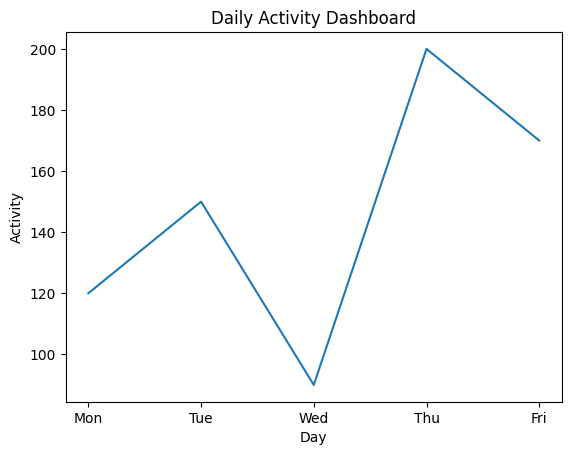

In [14]:
import requests
import matplotlib.pyplot as plt

# fetch data from backend
data = requests.get("http://127.0.0.1:5000/data").json()

# extract values
days = [d['day'] for d in data]
activity = [d['activity'] for d in data]

# plot chart
plt.figure()
plt.plot(days, activity)
plt.title("Daily Activity Dashboard")
plt.xlabel("Day")
plt.ylabel("Activity")
plt.show()